## Descriptive Statistics

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.stats import fisher_exact

In [13]:
df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_04cleaned.csv"))

bins = np.arange(45, df['age'].max() + 5, 5)
labels = [f"{int(b)}–{int(b+4)}" for b in bins[:-1]]
df['age_bin'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

tox = df[df['at_risk'] == 1]
no_tox = df[df['at_risk'] == 0]

Descriptives of At Risk Patients

In [14]:
cont_vars = ['age','bmi','ascvd_10yr','sbp','dbp']

print("Age median: ", df['age'].median())
print("BMI median: ", df['bmi'].median())
print("Age median: ", df['age'].std())
print("BMI median: ", df['bmi'].std())

table1_cont = df.groupby('at_risk')[cont_vars].agg(['mean','std'])

print(table1_cont)

table2_cont = df[cont_vars].agg(['mean','std'])

print(table2_cont)

cat_vars = [
    'ethnicity','hx_smoking','hx_htn','hx_hld','hx_dm2',
    'hx_cad','hx_chf','hx_arrhythmia','hx_pad','hx_cva',
    'has_pcp','lipid_panel_checked','a1c_checked',
    'cards_prior','diet_counseling','exercise_counseling'
]

table1_cat = {}

for v in cat_vars:
    table1_cat[v] = pd.crosstab(df['at_risk'], df[v], normalize='columns') * 100

for k,v in table1_cat.items():
    print("\n",k)
    print(v)

Age median:  71.0
BMI median:  27.53
Age median:  8.295910015872641
BMI median:  4.775503987591421
               age                  bmi           ascvd_10yr            \
              mean       std       mean       std       mean       std   
at_risk                                                                  
0.0      71.766129  9.337492  27.801290  5.194846   1.774194  0.419809   
1.0      71.405063  8.460343  27.521266  5.080351   1.835443  0.373149   

                sbp                   dbp            
               mean        std       mean       std  
at_risk                                              
0.0      129.733871  13.662666  73.629032  7.867260  
1.0      130.759494  14.506599  73.392405  8.662353  
            age        bmi  ascvd_10yr         sbp        dbp
mean  71.518828  27.646025    1.828452  129.962343  73.606695
std    8.295910   4.775504    0.377778   12.877030   7.524478

 ethnicity
ethnicity      Asian      Black  Caucasian   Hispanic      Oth

### Baseline Demographics
Age

C:\Users\tiffa\AppData\Local\Temp\ipykernel_28736\3982113523.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_bin', 'at_risk'])['unique_patient_id']


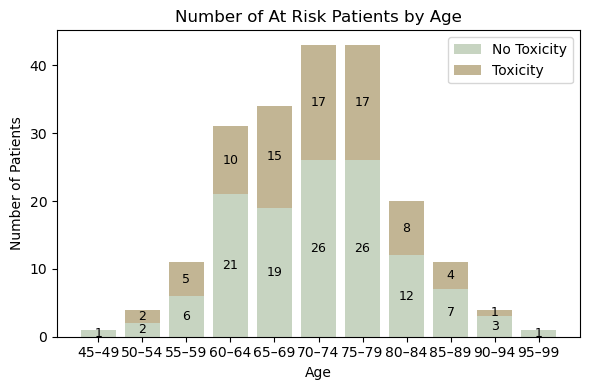

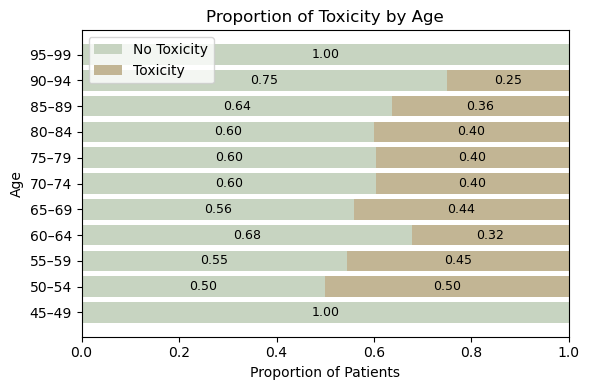

In [15]:
counts = (
    df.groupby(['age_bin', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).index]

fig, ax = plt.subplots(figsize=(6,4))

bars_no = ax.bar(counts.index.astype(str), counts[0], color='#c7d4c1', label='No Toxicity')

bars_yes = ax.bar(counts.index.astype(str), counts[1], bottom=counts[0], color='#c2b594', label='Toxicity')

labels_no = [str(v) if v > 0 else "" for v in counts[0]]
labels_yes = [str(v) if v > 0 else "" for v in counts[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Age')
ax.set_ylabel('Number of Patients')
ax.set_title('Number of At Risk Patients by Age')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Age')
ax.set_title('Proportion of Toxicity by Age')
ax.legend()

plt.tight_layout()
plt.show()

Ethnicity

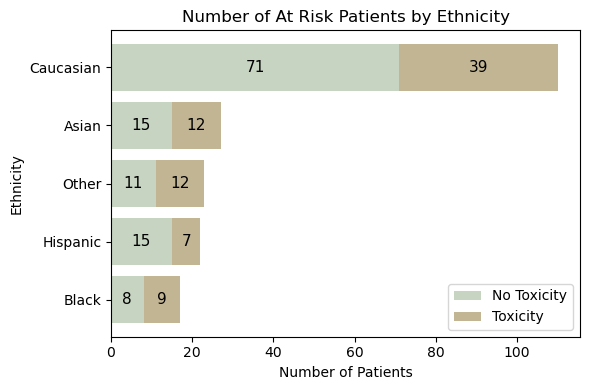

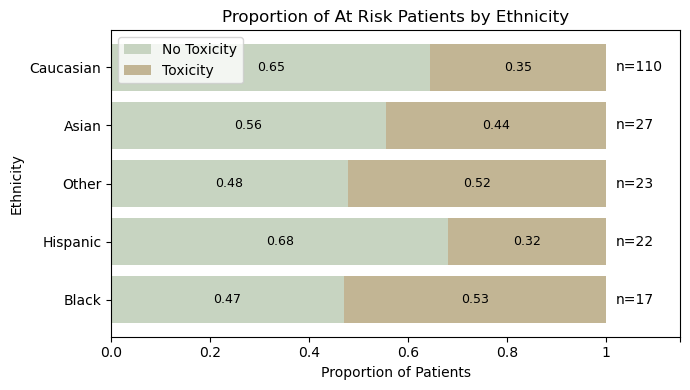

In [16]:

counts = (
    df.groupby(['ethnicity', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

# Count

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

counts = counts[counts.sum(axis=1) >= 2]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('Number of At Risk Patients by Ethnicity')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion
totals = counts.sum(axis=1)

fig, ax = plt.subplots(figsize=(7,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

for i, (idx, total) in enumerate(totals.items()):
    ax.text(
        1.02,              
        i,                 
        f'n={int(total)}',
        va='center'
    )

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.15], [0.0, 0.2, 0.4, 0.6, 0.8, 1, ""])
ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Ethnicity')
ax.set_title('Proportion of At Risk Patients by Ethnicity')
ax.legend()

plt.tight_layout()
plt.show()

BMI

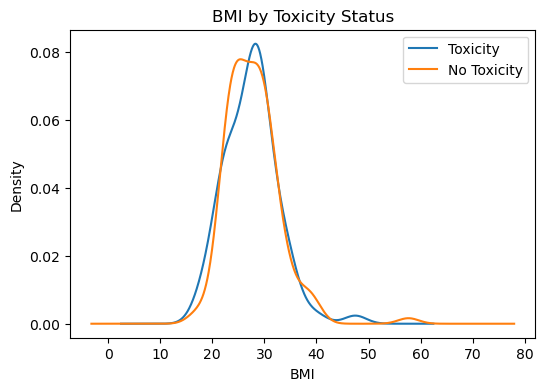

Median BMI (No Toxicity): 27.41
Median BMI (Toxicity): 27.60
Median Difference (Yes - No): 0.20
p-value: 0.8580


In [17]:
tox_bmi = df[df['at_risk'] == 1]['bmi']
no_tox_bmi = df[df['at_risk'] == 0]['bmi']

tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='Toxicity')
no_tox_bmi.dropna().plot(kind='density', figsize=(6,4), label='No Toxicity')

plt.xlabel('BMI')
plt.ylabel('Density')
plt.title('BMI by Toxicity Status')
plt.legend()

plt.show()

bmi_summary = df.groupby('at_risk')['bmi'].median()
median_no = bmi_summary[0]
median_yes = bmi_summary[1]

median_diff = median_yes - median_no

print(f"Median BMI (No Toxicity): {median_no:.2f}")
print(f"Median BMI (Toxicity): {median_yes:.2f}")
print(f"Median Difference (Yes - No): {median_diff:.2f}")

from scipy.stats import mannwhitneyu

bmi_no = df[df['at_risk'] == 0]['bmi'].dropna()
bmi_yes = df[df['at_risk'] == 1]['bmi'].dropna()

stat, pval = mannwhitneyu(bmi_yes, bmi_no, alternative='two-sided')

print(f"p-value: {pval:.4f}")

Age vs. BMI

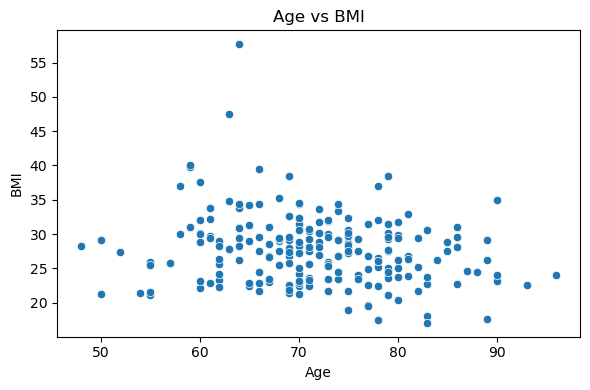

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='age', y='bmi')

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Age vs BMI")

plt.tight_layout()
plt.show()

Counts of Toxicity based on Baseline Risk Factor

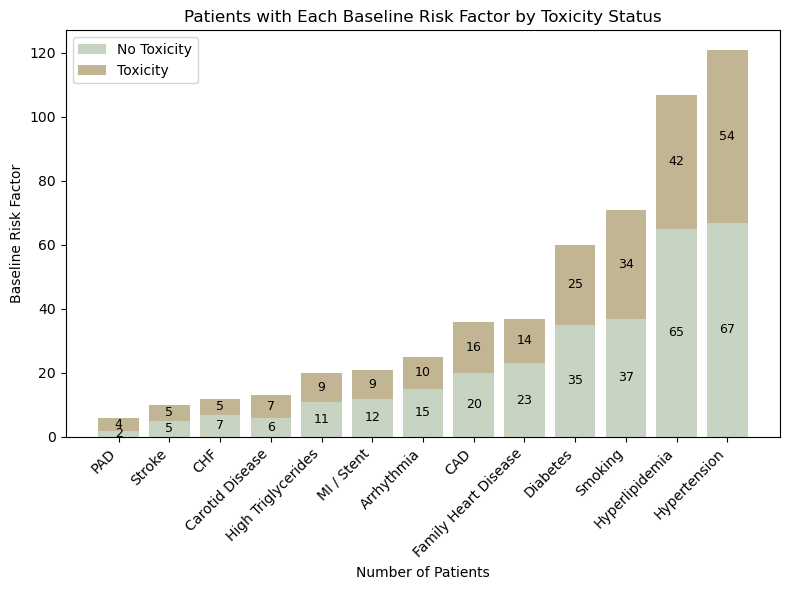

In [19]:
condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

risk_factors = ['hx_smoking', 'family_hx_hd', 'hx_htn','hx_hld','hx_high_tg',
                'hx_cad','hx_mi_stent','hx_chf','hx_arrhythmia','hx_carotid',
                'hx_pad','hx_cva','hx_dm2']

long_df = df.melt(
    id_vars=['unique_patient_id', 'at_risk'],
    value_vars=risk_factors,
    var_name='condition',
    value_name='has_condition'
)

long_df = long_df[long_df['has_condition'] == 1]

long_df['condition'] = long_df['condition'].map(condition_names)

counts = (
    long_df.groupby(['condition', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

counts = counts.rename(columns={0: 'No Toxicity', 1: 'Toxicity'})

fig, ax = plt.subplots(figsize=(8,6))

bars_no = ax.bar(counts.index, counts['No Toxicity'],
                  color='#c7d4c1', label='No Toxicity')

bars_yes = ax.bar(counts.index, counts['Toxicity'],
                   bottom=counts['No Toxicity'],
                   color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, label_type='center', fontsize=9)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Baseline Risk Factor')
ax.set_title('Patients with Each Baseline Risk Factor by Toxicity Status')
ax.legend()

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Proportion of Patients in Toxicity Group that had Baseline Risk Factor

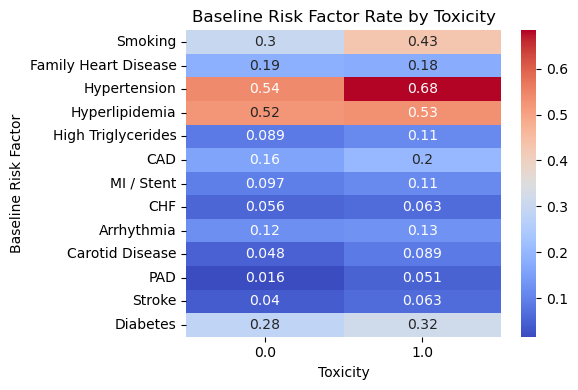

In [20]:
risk_vars = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 
             'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

heat = df.groupby('at_risk')[risk_vars].mean().T
heat.index = heat.index.map(condition_names)

plt.figure(figsize=(6,4))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.title("Baseline Risk Factor Rate by Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Baseline Risk Factor")
plt.tight_layout()

Proportion of Patients with Baseline Disease that Developed Toxicity

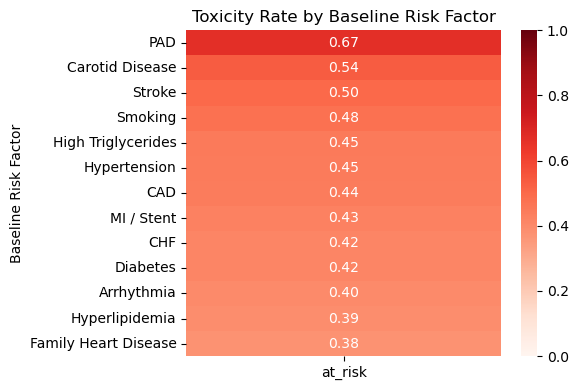

In [21]:
heatmap_data = []

health_cols = ["hx_smoking", "family_hx_hd", 'hx_htn', 'hx_hld', 'hx_high_tg', 'hx_cad', 'hx_mi_stent', 'hx_chf', 'hx_arrhythmia', 'hx_carotid', 'hx_pad', 'hx_cva', 'hx_dm2']

#affected if hx_smoking = 1 or 2, family_hx_hd = 1, hx_htn=1, hx_hld=1, hx_high_tg=1, hx_cad =1, hx_mi_stent=1, hx_chf=1, hx_arrhythmia=1, hx_carotid=1, hx_pad=1, hx_cva=1, hx_dm2=1

condition_filter = {
    "hx_smoking": lambda x: x >= 1,
    "family_hx_hd": lambda x: x == 1,
    'hx_htn': lambda x: x == 1,
    'hx_hld': lambda x: x == 1,
    'hx_high_tg': lambda x: x == 1,
    'hx_cad': lambda x: x == 1,
    'hx_mi_stent': lambda x: x == 1,
    'hx_chf': lambda x: x == 1,
    'hx_arrhythmia': lambda x: x == 1,
    'hx_carotid': lambda x: x == 1,
    'hx_pad': lambda x: x == 1,
    'hx_cva': lambda x: x == 1,
    'hx_dm2': lambda x: x == 1
}

condition_names = {
    "hx_smoking": "Smoking",
    "family_hx_hd": "Family Heart Disease",
    "hx_htn": "Hypertension",
    "hx_hld": "Hyperlipidemia",
    "hx_high_tg": "High Triglycerides",
    "hx_cad": "CAD",
    "hx_mi_stent": "MI / Stent",
    "hx_chf": "CHF",
    "hx_arrhythmia": "Arrhythmia",
    "hx_carotid": "Carotid Disease",
    "hx_pad": "PAD",
    "hx_cva": "Stroke",
    "hx_dm2": "Diabetes"
}

for col in health_cols:
    subset = df[condition_filter[col](df[col])]
    
    tox_value = subset['at_risk'].mean()
     
    heatmap_data.append({
        "condition": col,
        "at_risk": tox_value
    })

heatmap_df = pd.DataFrame(heatmap_data).set_index("condition")
heatmap_df.index = heatmap_df.index.map(condition_names)
heatmap_df = heatmap_df.sort_values("at_risk", ascending=False)

plt.figure(figsize=(6,4))

ax=sns.heatmap(
    heatmap_df,
    annot=True,
    cmap="Reds",
    vmin=0,
    vmax=1,
    fmt=".2f",
    annot_kws={"color": "white", "fontsize": 10}
)

ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.title("Toxicity Rate by Baseline Risk Factor")
plt.xlabel("")
plt.ylabel("Baseline Risk Factor")

plt.tight_layout()
plt.show()

### ADT and NHT Measures

NHT Counts

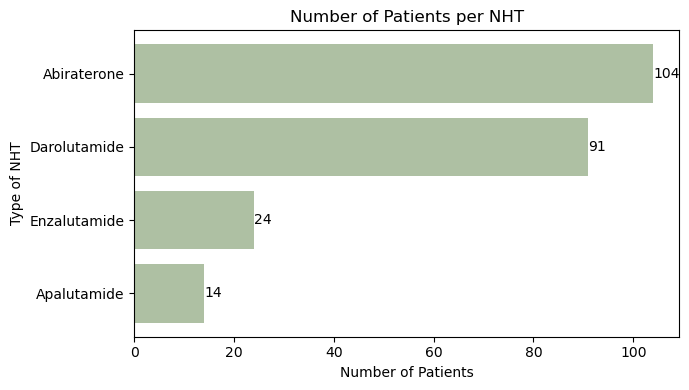

In [22]:
# Count unique patients per NHT
num_patients = df.groupby('specific_nht_used')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7,4))

p=ax.barh(num_patients.index, num_patients.values,
          color='#aec0a3')
ax.bar_label(p, label_type='edge')
ax.set_ylabel('Type of NHT')
ax.set_xlabel('Number of Patients')
ax.set_title('Number of Patients per NHT')
plt.tight_layout()
plt.show()

ADT Counts

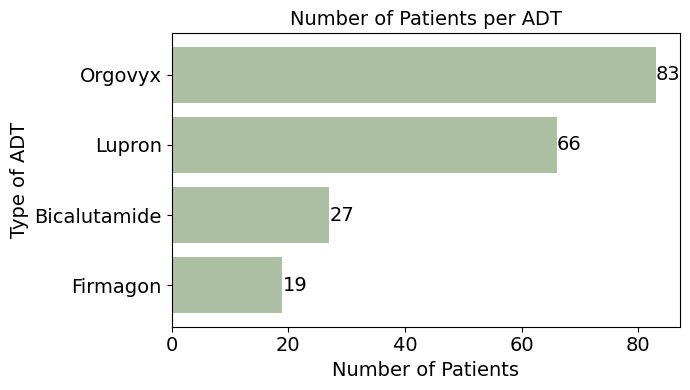

In [23]:
# Count unique patients per ADT
num_patients = df.groupby('adt_agent')['unique_patient_id'].nunique()

num_patients = num_patients.sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(7,4))

ax.barh(num_patients.index, num_patients.values)
p=ax.barh(num_patients.index, num_patients.values, color='#aec0a3')
ax.bar_label(p, label_type='edge', fontsize=14)
ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients per ADT', fontsize=14)
ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

NHT and ADT Combinations

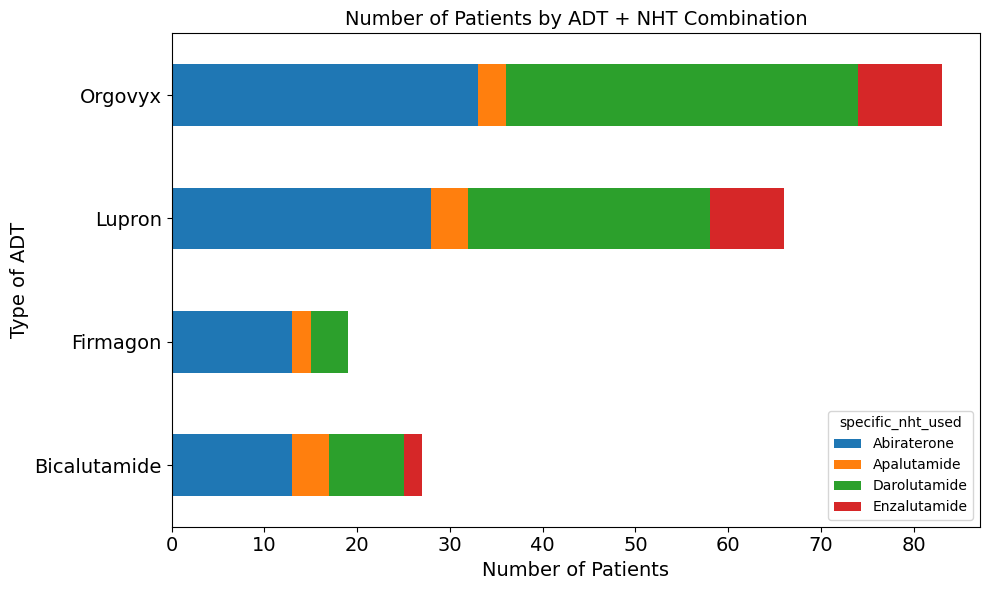

In [24]:
combo_counts = (
    df.groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(10,6))

combo_counts.plot(
    kind='barh',
    stacked=True,
    ax=ax
)

ax.set_ylabel('Type of ADT', fontsize=14)
ax.set_xlabel('Number of Patients', fontsize=14)
ax.set_title('Number of Patients by ADT + NHT Combination', fontsize=14)

ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

Toxicity by NHT

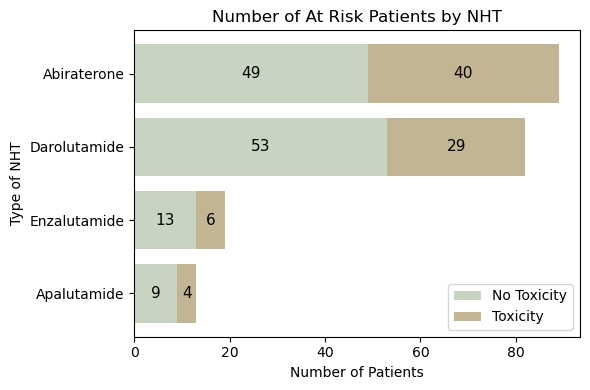

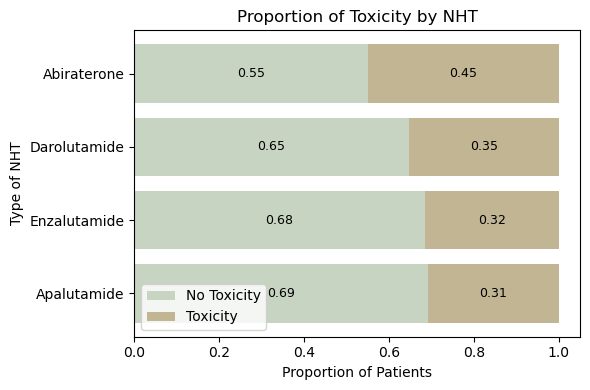

In [25]:
counts = (
    df.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity by NHT')
ax.legend()

plt.tight_layout()
plt.show()

Toxicity by ADT

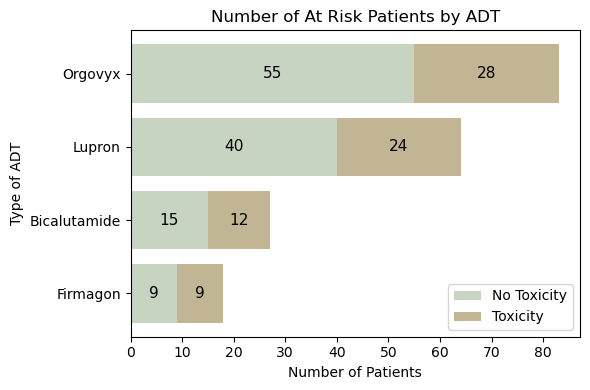

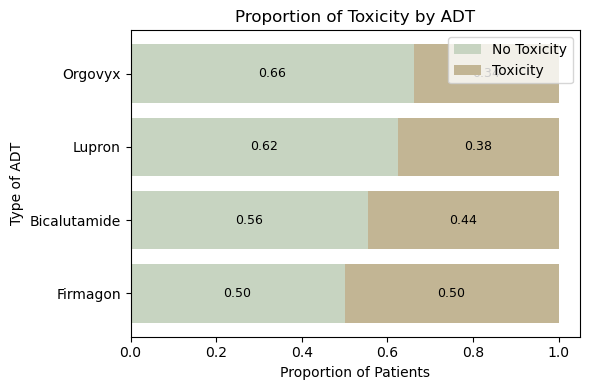

In [26]:
# Counts

counts = (
    df.groupby(['adt_agent', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of ADT')
ax.set_title('Number of At Risk Patients by ADT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of ADT')
ax.set_title('Proportion of Toxicity by ADT')
ax.legend()

plt.tight_layout()
plt.show()

Counts of Type of Toxicity by NHT

In [27]:
all_df = pd.read_csv(os.path.join("..", "data", "processed", "cardio_onc_prostate_06_broad_clean.csv"))

counts = (
    all_df.groupby(['specific_nht_used', 'bp_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

counts = (
    all_df.groupby(['specific_nht_used', 'lipid_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

counts = (
    all_df.groupby(['specific_nht_used', 'dm_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

bp_meds_post_binary  0.0  1.0
specific_nht_used            
Apalutamide           11    2
Enzalutamide          16    3
Darolutamide          69   12
Abiraterone           69   20
lipid_meds_post_binary  0.0  1.0
specific_nht_used               
Apalutamide              11    2
Enzalutamide             17    2
Darolutamide             74    8
Abiraterone              73   16
dm_meds_post_binary  0.0  1.0
specific_nht_used            
Apalutamide           12    1
Enzalutamide          16    3
Darolutamide          65   17
Abiraterone           68   20


Counts of Types of Toxicity by ADT

In [28]:
counts = (
    all_df.groupby(['adt_agent', 'bp_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

counts = (
    all_df.groupby(['adt_agent', 'lipid_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

counts = (
    all_df.groupby(['adt_agent', 'dm_meds_post_binary'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]
print(counts)

bp_meds_post_binary  0.0  1.0
adt_agent                    
Firmagon              10    7
Bicalutamide          22    5
Lupron                51   13
Orgovyx               74    9
lipid_meds_post_binary  0.0  1.0
adt_agent                       
Firmagon                 15    3
Bicalutamide             24    3
Lupron                   52   12
Orgovyx                  73   10
dm_meds_post_binary  0.0  1.0
adt_agent                    
Firmagon              12    6
Bicalutamide          21    6
Lupron                54   10
Orgovyx               66   16


Darolutimide vs. Abiraterone Significance

In [29]:
rates = df.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

from scipy.stats import chi2_contingency

subset = df[df['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p)

specific_nht_used
Abiraterone     0.449438
Apalutamide     0.307692
Darolutamide    0.353659
Enzalutamide    0.315789
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.09577966566182516
Chi-square p-value: 0.2629686968295048


Orgovyx vs. Lupron

In [30]:
rates = df.groupby('adt_agent')['at_risk'].mean()

risk_diff = rates['Lupron'] - rates['Orgovyx']

print(rates)
print("Risk difference of Lupron vs. Orgovyx:", risk_diff)

from scipy.stats import chi2_contingency

subset = df[df['adt_agent'].isin(['Orgovyx', 'Lupron'])]

table = pd.crosstab(subset['adt_agent'], subset['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p)

adt_agent
Bicalutamide    0.444444
Firmagon        0.500000
Lupron          0.375000
Orgovyx         0.337349
Name: at_risk, dtype: float64
Risk difference of Lupron vs. Orgovyx: 0.03765060240963858
Chi-square p-value: 0.764632290670373


Toxcity Rate by ADT and NHT Combination

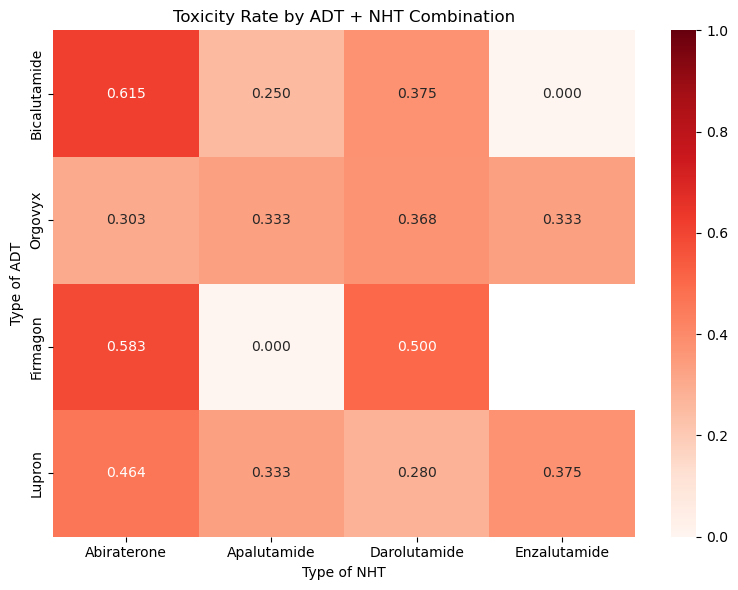

In [74]:
df_atrisk = df[df['at_risk'].notna()]

total_counts = (
    df_atrisk[['unique_patient_id', 'adt_agent', 'specific_nht_used']]
    .drop_duplicates()
    .groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

tox_counts = (
    df_atrisk[df_atrisk['at_risk'] == 1][['unique_patient_id', 'adt_agent', 'specific_nht_used']]
    .drop_duplicates()
    .groupby(['adt_agent', 'specific_nht_used'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

tox_counts = tox_counts.reindex(
    index=total_counts.index,
    columns=total_counts.columns,
    fill_value=0
)

valid_rows = total_counts.sum(axis=1) > 3
valid_cols = total_counts.sum(axis=0) > 3

total_counts = total_counts.loc[valid_rows, valid_cols]
tox_counts = tox_counts.loc[valid_rows, valid_cols]

tox_rate = tox_counts.div(total_counts.replace(0, np.nan))

tox_rate = tox_rate.loc[tox_rate.mean(axis=1).sort_values().index]

plt.figure(figsize=(8,6))

ax = sns.heatmap(
    tox_rate,
    annot=True,
    fmt=".3f",
    cmap="Reds",
    vmin=0,
    vmax=1
)

ax.set_xlabel("Type of NHT")
ax.set_ylabel("Type of ADT")
ax.set_title("Toxicity Rate by ADT + NHT Combination")

plt.tight_layout()
plt.show()


Top Four Combination Toxicity

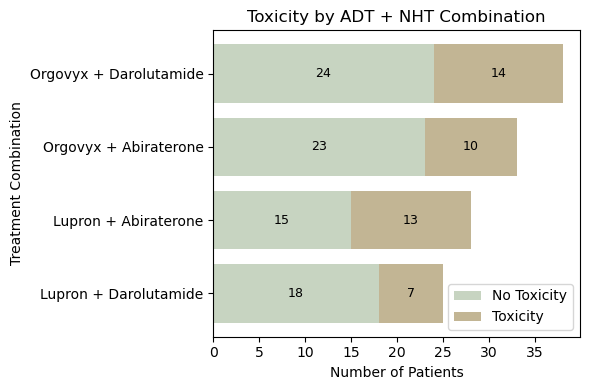

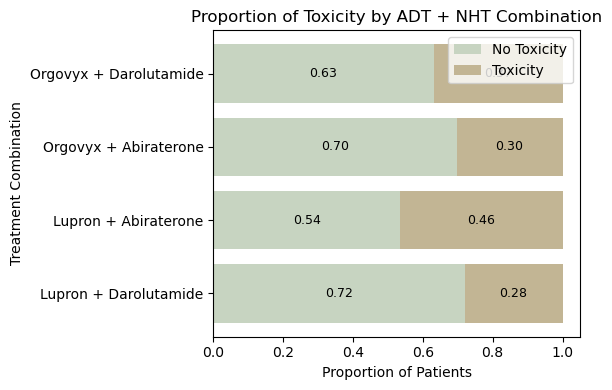

In [32]:
subset = df[
    df['adt_agent'].isin(['Orgovyx', 'Lupron']) &
    df['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])
].copy()

subset['combo'] = subset['adt_agent'] + " + " + subset['specific_nht_used']

counts = (
    subset.groupby(['combo', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(6,4))

bars_no = ax.barh(counts.index, counts[0],
                 color='#c7d4c1', label='No Toxicity')

bars_yes = ax.barh(counts.index, counts[1],
                  left=counts[0],
                  color='#c2b594', label='Toxicity')

for container in [bars_no, bars_yes]:
    ax.bar_label(container, label_type='center', fontsize=9)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Treatment Combination')
ax.set_title('Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Treatment Combination')
ax.set_title('Proportion of Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

All Combinations

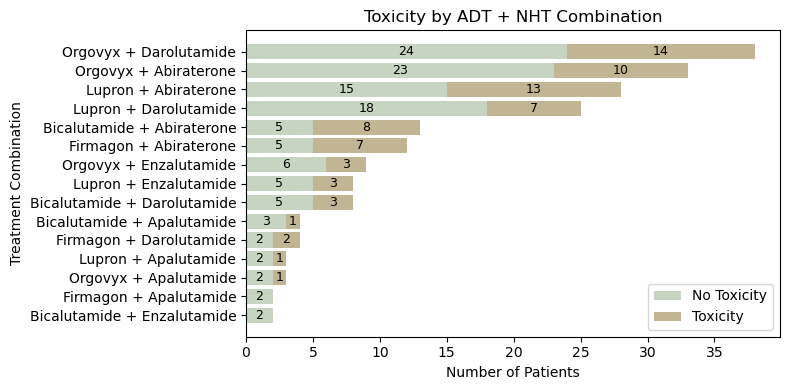

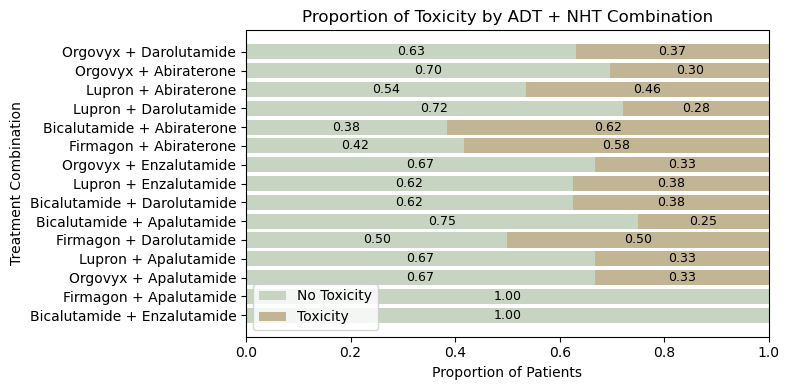

In [33]:
df['combo'] = df['adt_agent'] + " + " + df['specific_nht_used']

counts = (
    df.groupby(['combo', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(8,4))

bars_no = ax.barh(counts.index, counts[0],
                 color='#c7d4c1', label='No Toxicity')

bars_yes = ax.barh(counts.index, counts[1],
                  left=counts[0],
                  color='#c2b594', label='Toxicity')

labels_no = [str(v) if v > 0 else "" for v in counts[0]]
labels_yes = [str(v) if v > 0 else "" for v in counts[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Treatment Combination')
ax.set_title('Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Treatment Combination')
ax.set_title('Proportion of Toxicity by ADT + NHT Combination')
ax.legend()

plt.tight_layout()
plt.show()

### Time Period Length Between ADT and NHT Start

Overall

In [34]:
df['days_adt_to_nht'].describe()

count      192.000000
mean       509.213542
std       3146.876234
min       -731.000000
25%          0.000000
50%         28.000000
75%        184.750000
max      42759.000000
Name: days_adt_to_nht, dtype: float64

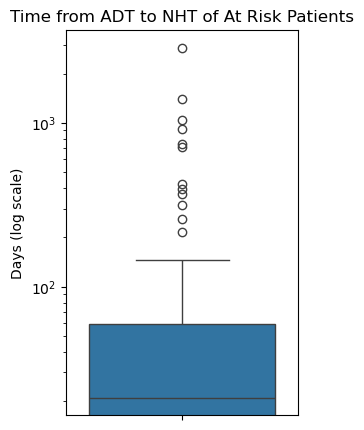

In [35]:
plt.figure(figsize=(3,5))

sns.boxplot(data=tox, y='days_adt_to_nht')

plt.yscale('log')

plt.title("Time from ADT to NHT of At Risk Patients")
plt.ylabel("Days (log scale)")

plt.show()

Split by NHTs

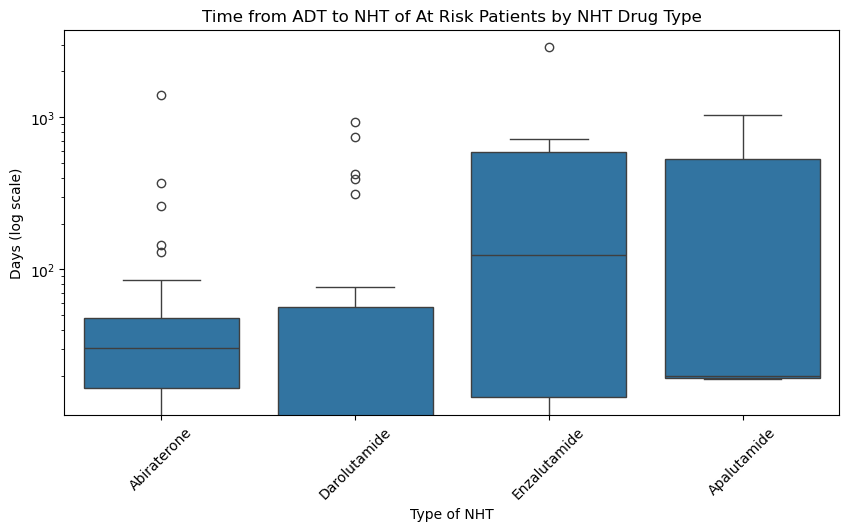

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='specific_nht_used', y='days_adt_to_nht')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by NHT Drug Type")
plt.xlabel("Type of NHT")
plt.ylabel("Days (log scale)")
plt.show()

Split by ADTs

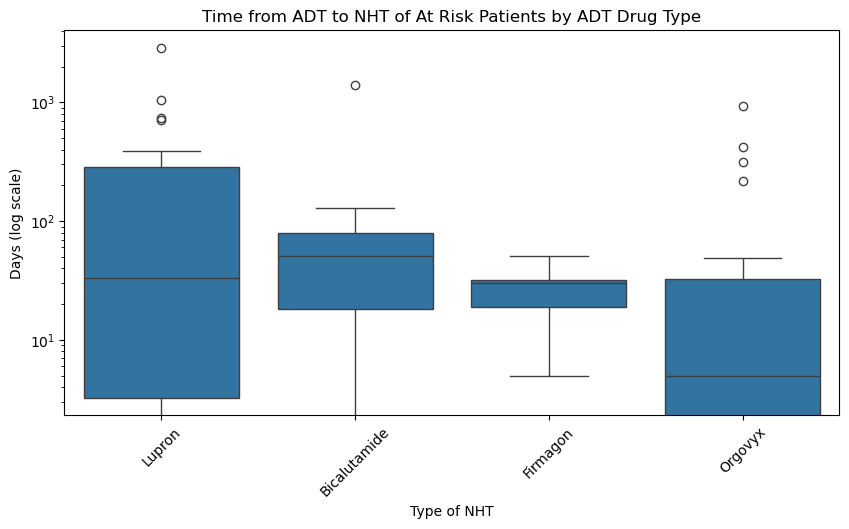

In [37]:
plt.figure(figsize=(10,5))
sns.boxplot(data=tox, x='adt_agent', y='days_adt_to_nht')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Time from ADT to NHT of At Risk Patients by ADT Drug Type")
plt.xlabel("Type of NHT")
plt.ylabel("Days (log scale)")
plt.show()

### Health History vs. NHT

History of Hypertension

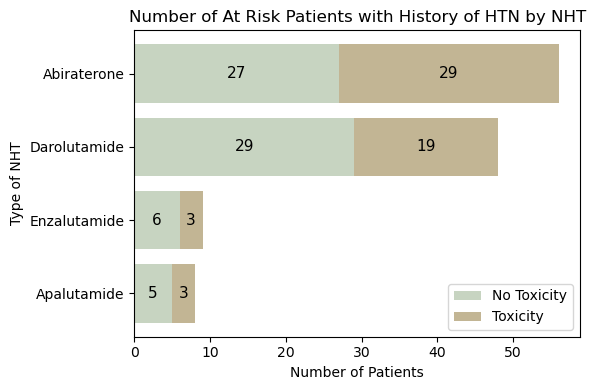

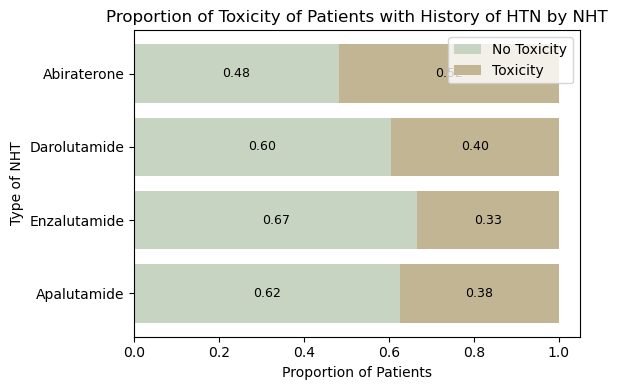

specific_nht_used
Abiraterone     0.517857
Apalutamide     0.375000
Darolutamide    0.395833
Enzalutamide    0.333333
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.12202380952380959
Chi-square p-value: 0.29504419985266417
Fisher's Exact p-value: 0.2408024934631612
Chi-square p-value (full): 0.5155089621598488
Fisher's Exact p-value (full): 0.5138


In [38]:
# Counts
htn = df[df['hx_htn'] == 1]

counts = (
    htn.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of HTN by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion
fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of HTN by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = htn.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = htn[htn['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(htn['specific_nht_used'], htn['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of Hyperlipidemia

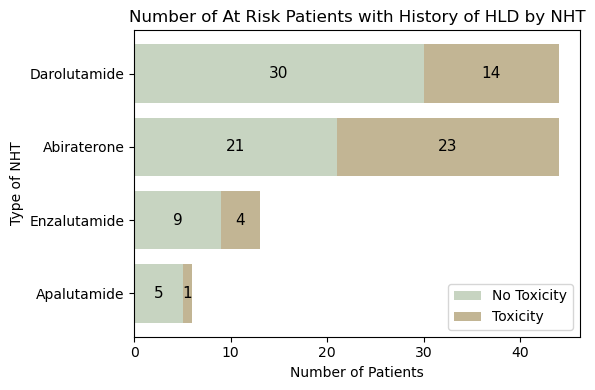

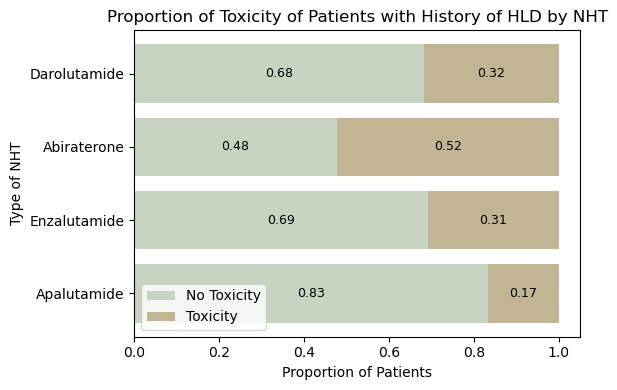

specific_nht_used
Abiraterone     0.522727
Apalutamide     0.166667
Darolutamide    0.318182
Enzalutamide    0.307692
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.20454545454545453
Chi-square p-value: 0.08405840872305885
Fisher's Exact p-value: 0.0834343849658688
Chi-square p-value (full): 0.12049377029722758
Fisher's Exact p-value (full): 0.1399


In [39]:
# Counts
hld = df[df['hx_hld'] == 1]

counts = (
    hld.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of HLD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of HLD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = hld.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = hld[hld['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(hld['specific_nht_used'], hld['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of Diabetes

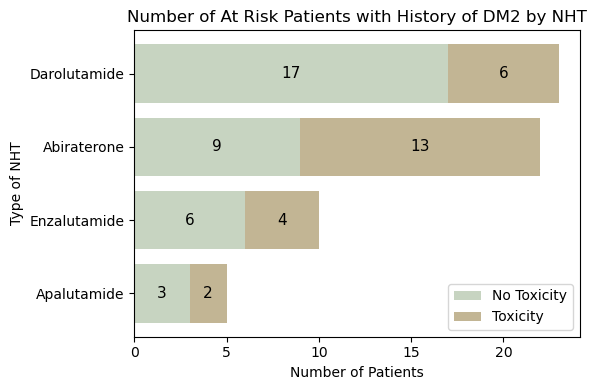

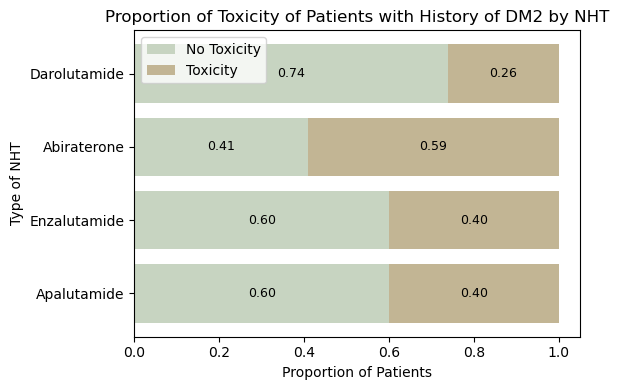

specific_nht_used
Abiraterone     0.590909
Apalutamide     0.400000
Darolutamide    0.260870
Enzalutamide    0.400000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.33003952569169964
Chi-square p-value: 0.05252441273778728
Fisher's Exact p-value: 0.036143225715429536
Chi-square p-value (full): 0.1673067168677974
Fisher's Exact p-value (full): 0.159
Abiraterone vs Enzalutamide: p = 0.450
Abiraterone vs Darolutamide: p = 0.036
Abiraterone vs Apalutamide: p = 0.628
Enzalutamide vs Darolutamide: p = 0.444
Enzalutamide vs Apalutamide: p = 1.000
Darolutamide vs Apalutamide: p = 0.606


In [40]:
# Counts

dm2 = df[df['hx_dm2'] == 1]

counts = (
    dm2.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of DM2 by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of DM2 by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = dm2.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = dm2[dm2['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(dm2['specific_nht_used'], dm2['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)


from itertools import combinations

drugs = dm2['specific_nht_used'].unique()

for a, b in combinations(drugs, 2):
    sub = dm2[dm2['specific_nht_used'].isin([a,b])]
    table = pd.crosstab(sub['specific_nht_used'], sub['at_risk'])
    _, p = fisher_exact(table)
    print(f"{a} vs {b}: p = {p:.3f}")

History of MI / Stent

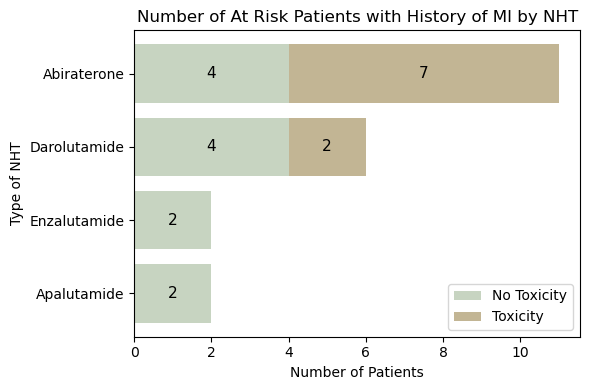

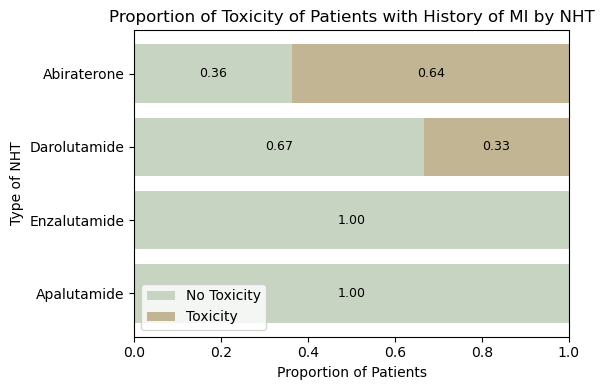

specific_nht_used
Abiraterone     0.636364
Apalutamide     0.000000
Darolutamide    0.333333
Enzalutamide    0.000000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.30303030303030304
Chi-square p-value: 0.491556878088525
Fisher's Exact p-value: 0.33484162895927605
Chi-square p-value (full): 0.16033819339966085
Fisher's Exact p-value (full): 0.1637


In [41]:
# Counts

mi = df[df['hx_mi_stent'] == 1]

counts = (
    mi.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of MI by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of MI by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = mi.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = mi[mi['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(mi['specific_nht_used'], mi['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of CHF

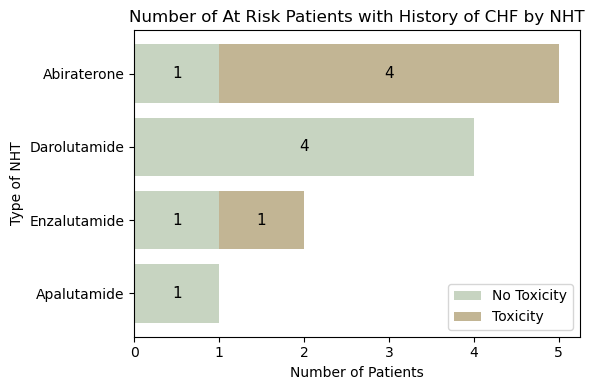

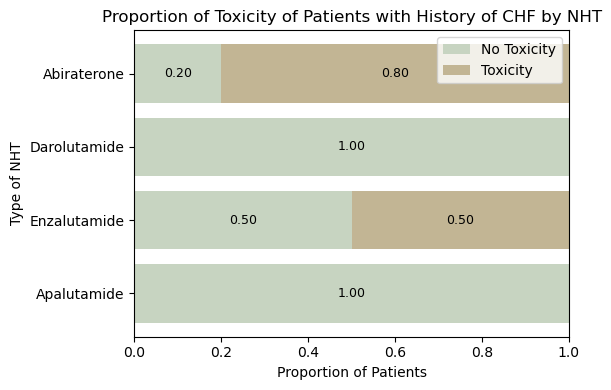

specific_nht_used
Abiraterone     0.8
Apalutamide     0.0
Darolutamide    0.0
Enzalutamide    0.5
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.8
Chi-square p-value: 0.08452747251590519
Fisher's Exact p-value: 0.04761904761904761
Chi-square p-value (full): 0.08387806925070464
Fisher's Exact p-value (full): 0.0798
Abiraterone vs Darolutamide: p = 0.048
Abiraterone vs Enzalutamide: p = 1.000
Abiraterone vs Apalutamide: p = 0.333
Darolutamide vs Enzalutamide: p = 0.333
Darolutamide vs Apalutamide: p = 1.000
Enzalutamide vs Apalutamide: p = 1.000


In [42]:
# Counts

chf = df[df['hx_chf'] == 1]

counts = (
    chf.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of CHF by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of CHF by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = chf.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = chf[chf['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(chf['specific_nht_used'], chf['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

drugs = chf['specific_nht_used'].unique()

for a, b in combinations(drugs, 2):
    sub = chf[chf['specific_nht_used'].isin([a,b])]
    table = pd.crosstab(sub['specific_nht_used'], sub['at_risk'])
    oddsratio, p = fisher_exact(table)
    print(f"{a} vs {b}: p = {p:.3f}")

History of Arrhythmia

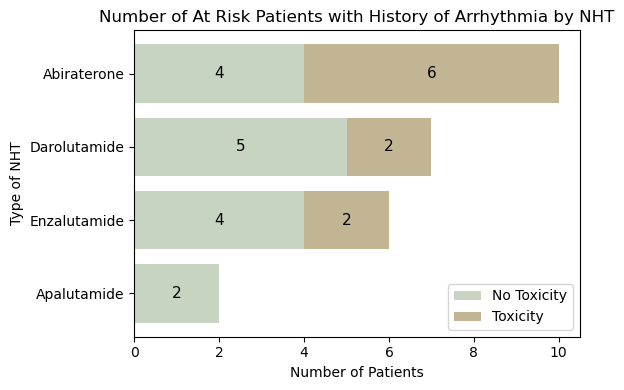

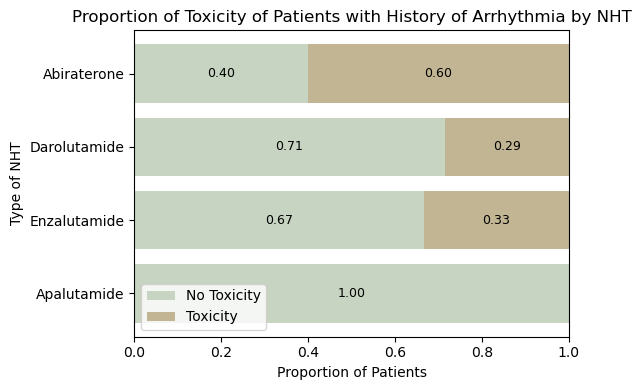

specific_nht_used
Abiraterone     0.600000
Apalutamide     0.000000
Darolutamide    0.285714
Enzalutamide    0.333333
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.3142857142857143
Chi-square p-value: 0.4330116178039759
Fisher's Exact p-value: 0.33484162895927605
Chi-square p-value (full): 0.32179291901443485
Fisher's Exact p-value (full): 0.4575


In [43]:
# Counts

arr = df[df['hx_arrhythmia'] == 1]

counts = (
    arr.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of Arrhythmia by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of Arrhythmia by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = arr.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = arr[arr['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(arr['specific_nht_used'], arr['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of CAD

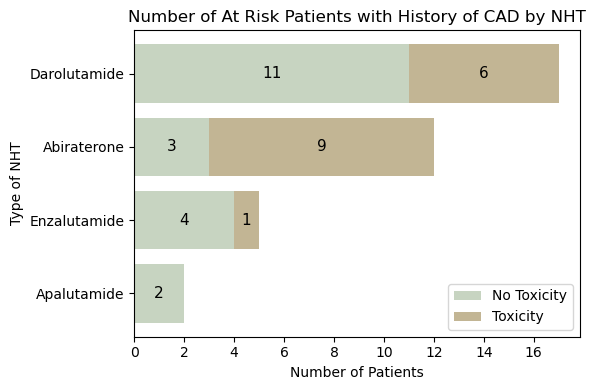

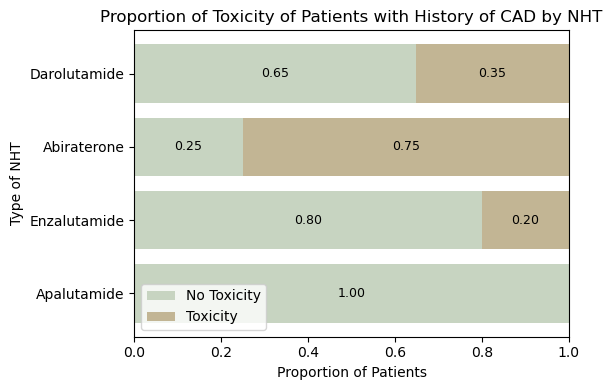

specific_nht_used
Abiraterone     0.750000
Apalutamide     0.000000
Darolutamide    0.352941
Enzalutamide    0.200000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.39705882352941174
Chi-square p-value: 0.08359482906974498
Fisher's Exact p-value: 0.06043294142402483
Chi-square p-value (full): 0.04760941737397806
Fisher's Exact p-value (full): 0.0495


In [44]:
# Counts

cad = df[df['hx_cad'] == 1]

counts = (
    cad.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of CAD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of CAD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = cad.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = cad[cad['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(cad['specific_nht_used'], cad['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of Carotid Disease

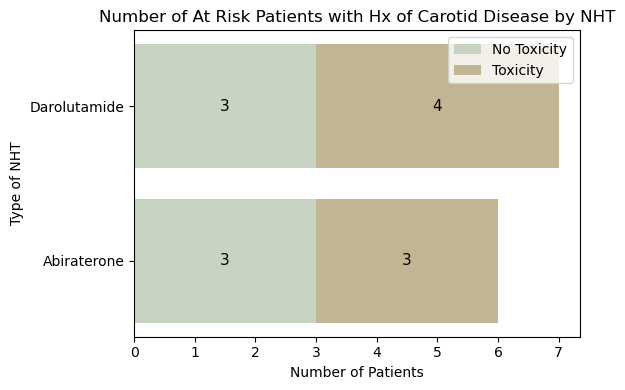

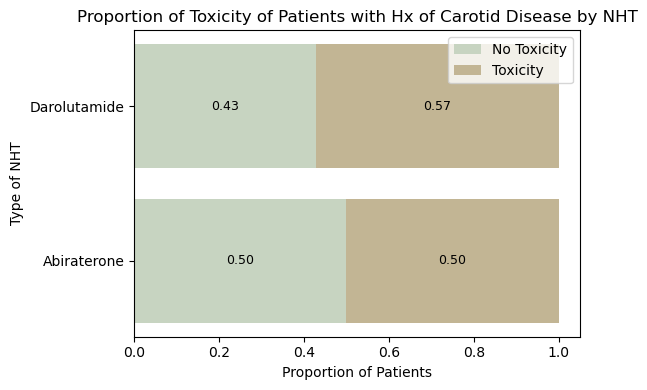

specific_nht_used
Abiraterone     0.500000
Darolutamide    0.571429
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.0714285714285714
Chi-square p-value: 1.0
Fisher's Exact p-value: 1.0
Chi-square p-value (full): 1.0
Fisher's Exact p-value (full): 1.0


In [45]:
# Counts

car = df[df['hx_carotid'] == 1]

counts = (
    car.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with Hx of Carotid Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with Hx of Carotid Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = car.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Darolutamide'] - rates['Abiraterone']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = car[car['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(car['specific_nht_used'], car['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of PVD / PAD

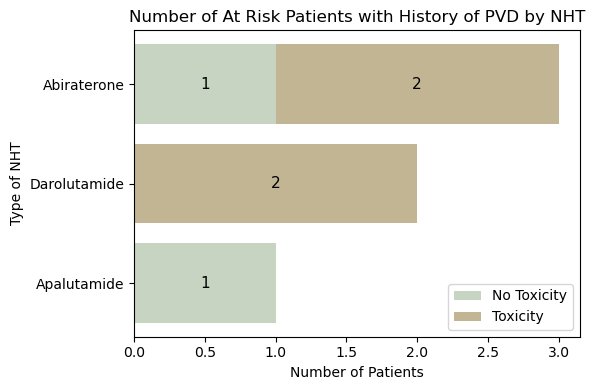

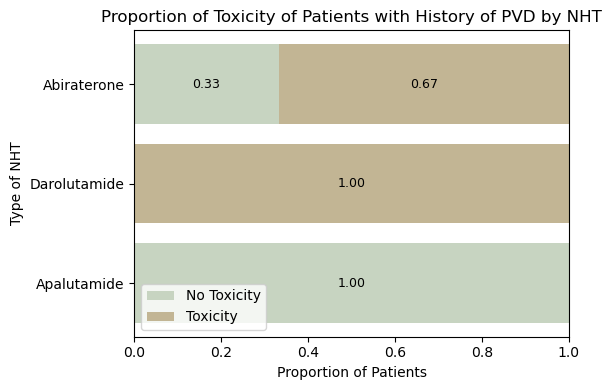

specific_nht_used
Abiraterone     0.666667
Apalutamide     0.000000
Darolutamide    1.000000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.33333333333333337
Chi-square p-value: 1.0
Fisher's Exact p-value: 1.0
Chi-square p-value (full): 0.22313016014842973
Fisher's Exact p-value (full): 0.5988


In [46]:
# Counts

pvd = df[df['hx_pad'] == 1]

counts = (
    pvd.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of PVD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of PVD by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = pvd.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Darolutamide'] - rates['Abiraterone']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = pvd[pvd['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(pvd['specific_nht_used'], pvd['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of Smoking

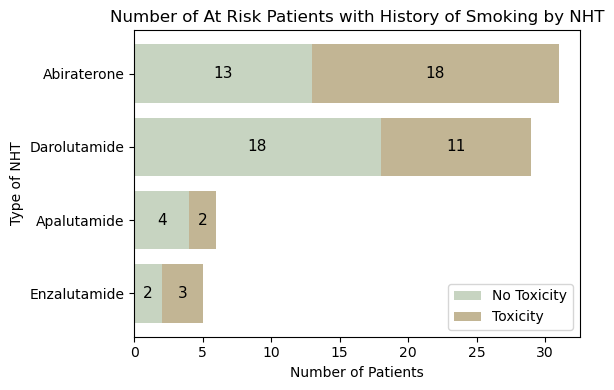

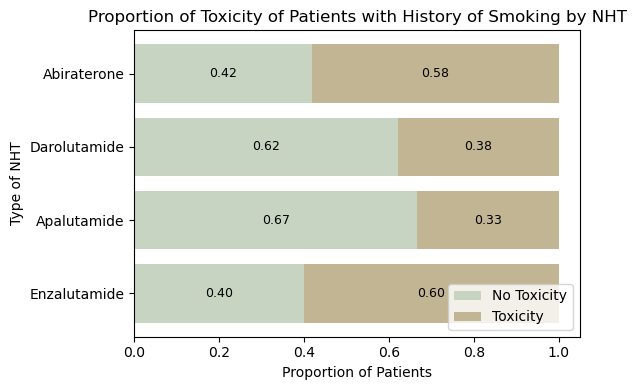

specific_nht_used
Abiraterone     0.580645
Apalutamide     0.333333
Darolutamide    0.379310
Enzalutamide    0.600000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.20133481646273643
Chi-square p-value: 0.19324247504046263
Fisher's Exact p-value: 0.1318867953749395
Chi-square p-value (full): 0.3558253940130848
Fisher's Exact p-value (full): 0.3621


In [47]:
# Counts

sm = df[df['hx_smoking'] == 1]

counts = (
    sm.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of Smoking by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of Smoking by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = sm.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = sm[sm['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(sm['specific_nht_used'], sm['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of Stroke

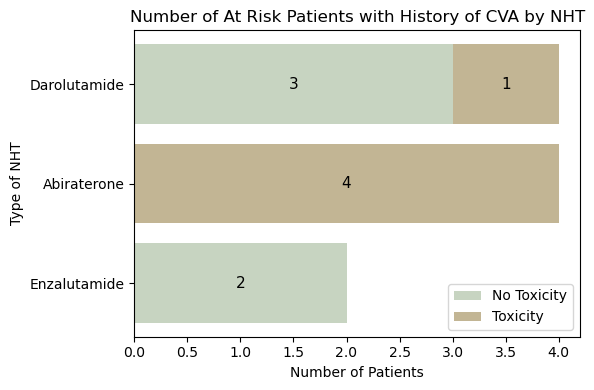

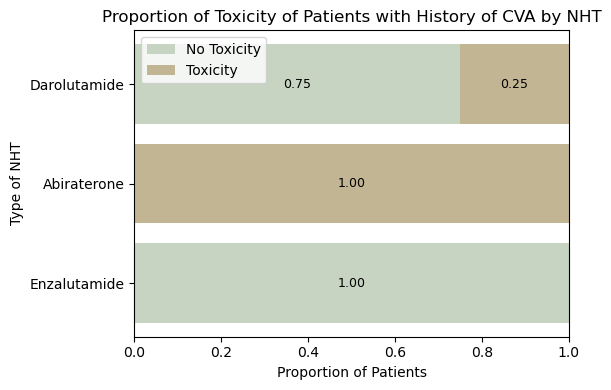

specific_nht_used
Abiraterone     1.00
Darolutamide    0.25
Enzalutamide    0.00
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.75
Chi-square p-value: 0.14412703481601116
Fisher's Exact p-value: 0.14285714285714288
Chi-square p-value (full): 0.0301973834223185
Fisher's Exact p-value (full): 0.085


In [48]:
# Counts

cva = df[df['hx_cva'] == 1]

counts = (
    cva.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of CVA by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of CVA by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = cva.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = cva[cva['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(cva['specific_nht_used'], cva['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

Family History of Heart Disease

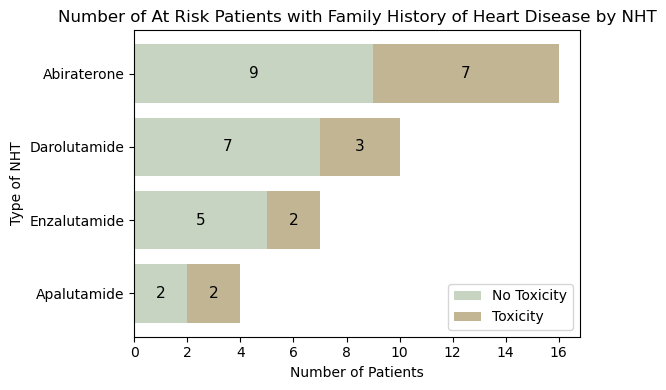

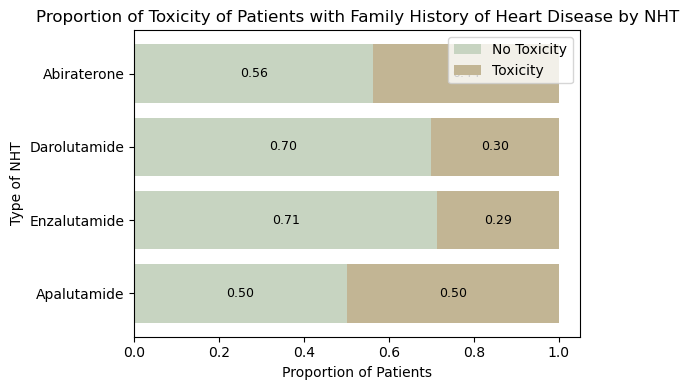

specific_nht_used
Abiraterone     0.437500
Apalutamide     0.500000
Darolutamide    0.300000
Enzalutamide    0.285714
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.1375
Chi-square p-value: 0.7742502649413151
Fisher's Exact p-value: 0.6834028806030421
Chi-square p-value (full): 0.7997879525890843
Fisher's Exact p-value (full): 0.7945


In [49]:
# Counts

fhd = df[df['family_hx_hd'] == 1]

counts = (
    fhd.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with Family History of Heart Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with Family History of Heart Disease by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = fhd.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = fhd[fhd['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(fhd['specific_nht_used'], fhd['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

History of High Triglycerides

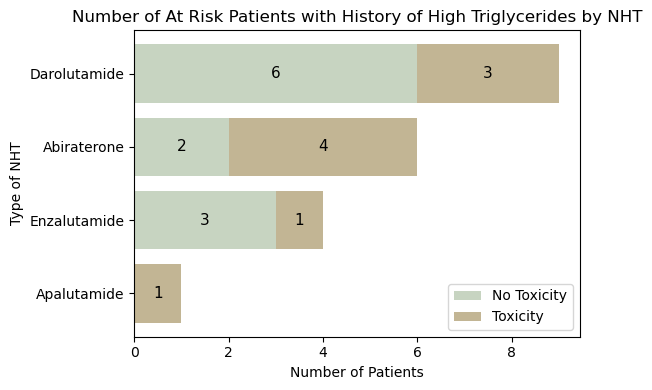

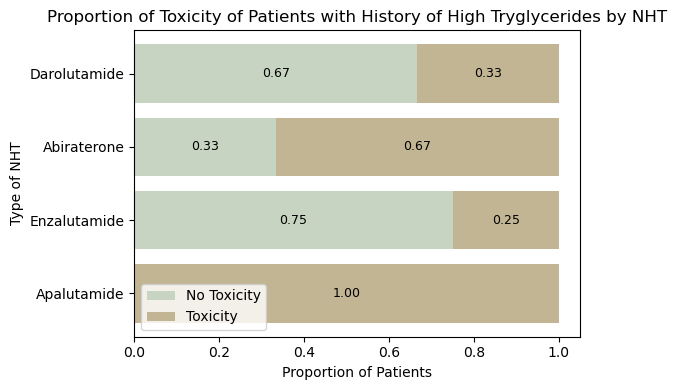

specific_nht_used
Abiraterone     0.666667
Apalutamide     1.000000
Darolutamide    0.333333
Enzalutamide    0.250000
Name: at_risk, dtype: float64
Risk difference of Abiraterone vs. Darolutamide: 0.3333333333333333
Chi-square p-value: 0.45959738618394197
Fisher's Exact p-value: 0.3146853146853147
Chi-square p-value (full): 0.3205438419149755
Fisher's Exact p-value (full): 0.3814


In [50]:
# Counts

tg = df[df['hx_high_tg'] == 1]

counts = (
    tg.groupby(['specific_nht_used', 'at_risk'])['unique_patient_id']
    .nunique()
    .unstack(fill_value=0)
)

counts = counts.loc[counts.sum(axis=1).sort_values(ascending=True).index]

# Plot stacked horizontal bars
fig, ax = plt.subplots(figsize=(6,4))

bars_no=ax.barh(counts.index, counts[0], color='#c7d4c1', label='No Toxicity')
bars_yes=ax.barh(counts.index, counts[1], left=counts[0], color='#c2b594', label='Toxicity')

ax.bar_label(bars_no, labels=[str(v) if v > 0 else "" for v in counts[0]], label_type='center', fontsize=11)
ax.bar_label(bars_yes, labels=[str(v) if v > 0 else "" for v in counts[1]], label_type='center', fontsize=11)

ax.set_xlabel('Number of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Number of At Risk Patients with History of High Triglycerides by NHT')
ax.legend()

plt.tight_layout()
plt.show()

# Proportion

fig, ax = plt.subplots(figsize=(6,4))
props = counts.div(counts.sum(axis=1), axis=0)
bars_no = ax.barh(props.index, props[0], label='No Toxicity', color='#c7d4c1')
bars_yes = ax.barh(props.index, props[1], left=props[0], color='#c2b594', label='Toxicity')

labels_no = [f"{p:.2f}" if p > 0 else "" for p in props[0]]
labels_yes = [f"{p:.2f}" if p > 0 else "" for p in props[1]]

ax.bar_label(bars_no, labels=labels_no, label_type='center', fontsize=9)
ax.bar_label(bars_yes, labels=labels_yes, label_type='center', fontsize=9)

ax.set_xlabel('Proportion of Patients')
ax.set_ylabel('Type of NHT')
ax.set_title('Proportion of Toxicity of Patients with History of High Tryglycerides by NHT')
ax.legend()

plt.tight_layout()
plt.show()

rates = tg.groupby('specific_nht_used')['at_risk'].mean()

risk_diff = rates['Abiraterone'] - rates['Darolutamide']

print(rates)
print("Risk difference of Abiraterone vs. Darolutamide:", risk_diff)

subset = tg[tg['specific_nht_used'].isin(['Darolutamide', 'Abiraterone'])]

table = pd.crosstab(subset['specific_nht_used'], subset['at_risk'])
full_table = pd.crosstab(tg['specific_nht_used'], tg['at_risk'])

chi2, p, dof, expected = chi2_contingency(table)
print("Chi-square p-value:", p)
oddsratio, p = fisher_exact(table)
print("Fisher's Exact p-value:", p)
chi2, p, dof, expected = chi2_contingency(full_table)
print("Chi-square p-value (full):", p)
oddsratio, p = fisher_exact(full_table)
print("Fisher's Exact p-value (full):", p)

### Cardiology Intervention

Proportion of Patients Receiving Intervention, given Baseline Risk Factor

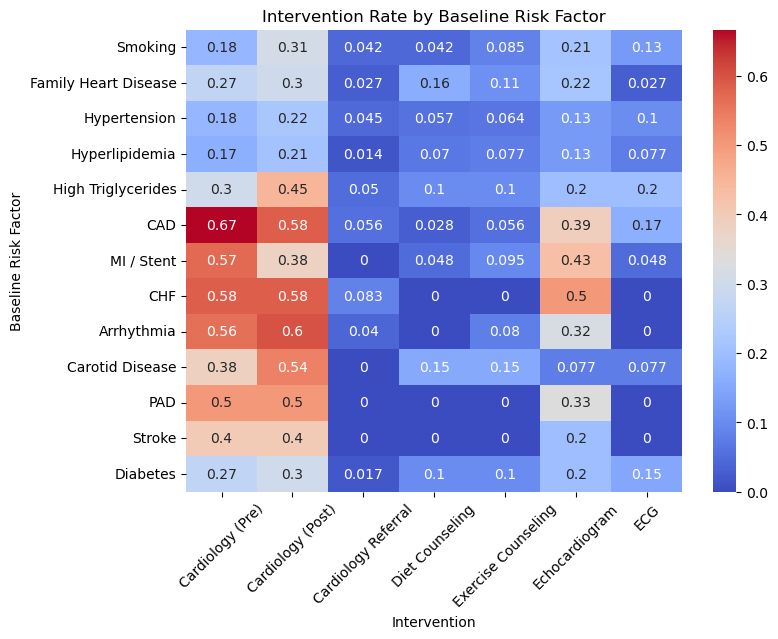

In [51]:
risk_factors = ['hx_smoking', 'family_hx_hd', 'hx_htn','hx_hld','hx_high_tg', 'hx_cad','hx_mi_stent',
                'hx_chf','hx_arrhythmia','hx_carotid','hx_pad','hx_cva','hx_dm2']
interventions = ['cards_prior', 'cards_post', 'cards_referral', 'diet_counseling','exercise_counseling','echo_ordered', 'ecg_done']

intervention_names = {
    "cards_prior": "Cardiology (Pre)",
    "cards_post": "Cardiology (Post)",
    "cards_referral": "Cardiology Referral",
    "diet_counseling": "Diet Counseling",
    "exercise_counseling": "Exercise Counseling",
    "echo_ordered": "Echocardiogram",
    "ecg_done": "ECG"
}

heat = pd.DataFrame(index=risk_factors, columns=interventions)

for r in risk_factors:
    for i in interventions:
        heat.loc[r,i] = df[df[r]==1][i].mean()

heat = heat.astype(float)
heat.index = heat.index.map(condition_names)
heat.columns = heat.columns.map(intervention_names)

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Intervention Rate by Baseline Risk Factor")
plt.xlabel("Intervention")
plt.ylabel("Baseline Risk Factor")
plt.show()

Proportion of At Risk Patients Receiving Intervention, given Baseline Risk Factor

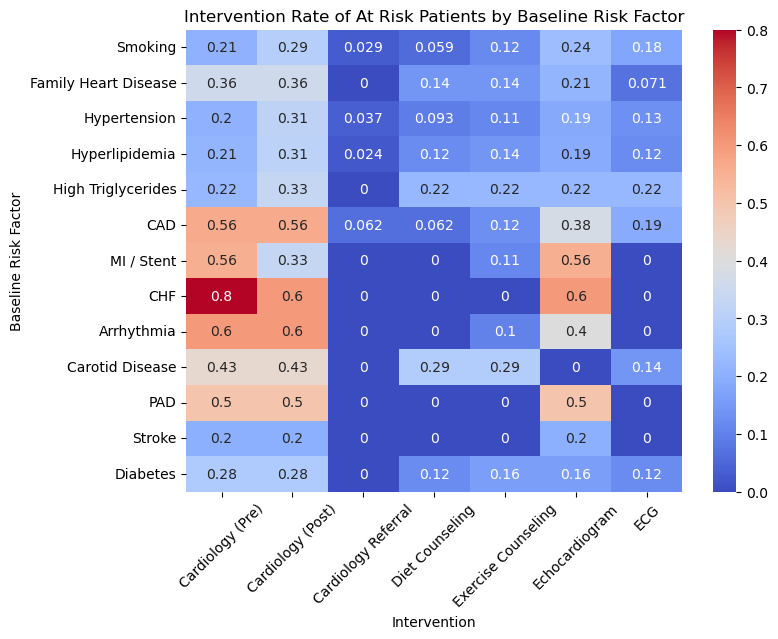

In [52]:
heat = pd.DataFrame(index=risk_factors, columns=interventions)

for r in risk_factors:
    for i in interventions:
        heat.loc[r,i] = tox[tox[r]==1][i].mean()

heat = heat.astype(float)
heat.index = heat.index.map(condition_names)
heat.columns = heat.columns.map(intervention_names)

plt.figure(figsize=(8,6))
sns.heatmap(heat, annot=True, cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Intervention Rate of At Risk Patients by Baseline Risk Factor")
plt.xlabel("Intervention")
plt.ylabel("Baseline Risk Factor")
plt.show()

Cardiologist Visits of At Risk Patients

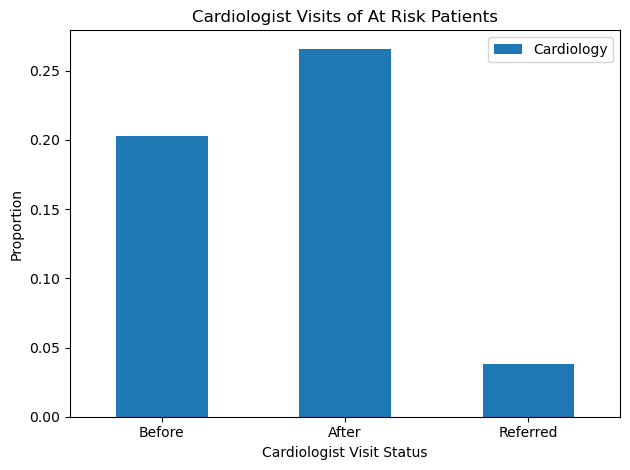

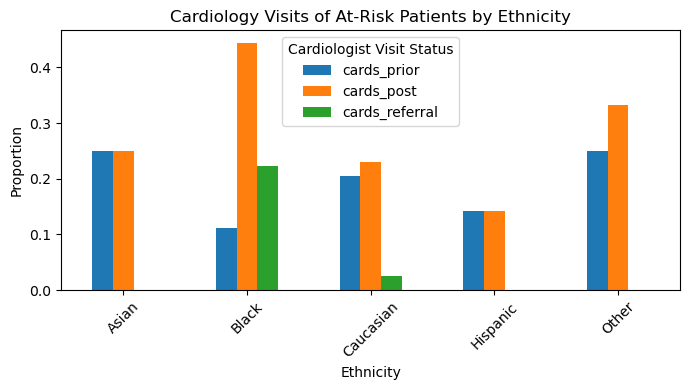

C:\Users\tiffa\AppData\Local\Temp\ipykernel_28736\2151297349.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby('age_bin')[['cards_prior', 'cards_post', 'cards_referral']]


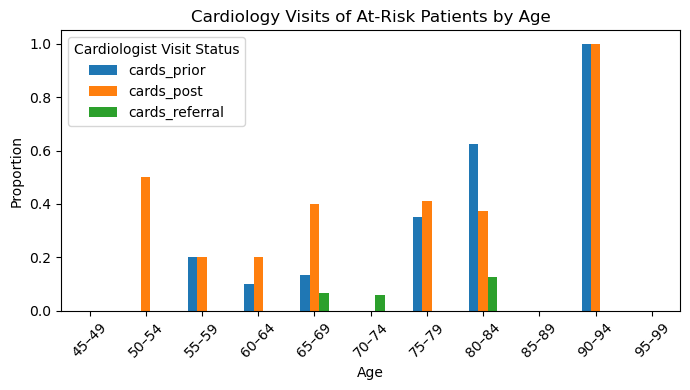

In [53]:
care = pd.DataFrame({
    "Before": tox['cards_prior'].mean(),
    "After": tox['cards_post'].mean(),
    "Referred": tox['cards_referral'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Cardiologist Visits of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Cardiologist Visit Status")
plt.ylabel("Proportion")
plt.tight_layout()

care_race = (
    tox.groupby('ethnicity')[['cards_prior', 'cards_post', 'cards_referral']]
    .mean()
)
care_race.plot(kind='bar', figsize=(7,4))

plt.title("Cardiology Visits of At-Risk Patients by Ethnicity")
plt.xlabel("Ethnicity")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cardiologist Visit Status")

plt.tight_layout()
plt.show()

care_age = (
    tox.groupby('age_bin')[['cards_prior', 'cards_post', 'cards_referral']]
    .mean()
)
care_age.plot(kind='bar', figsize=(7,4))

plt.title("Cardiology Visits of At-Risk Patients by Age")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Cardiologist Visit Status")

plt.tight_layout()
plt.show()

Preventative Care of At Risk Patients

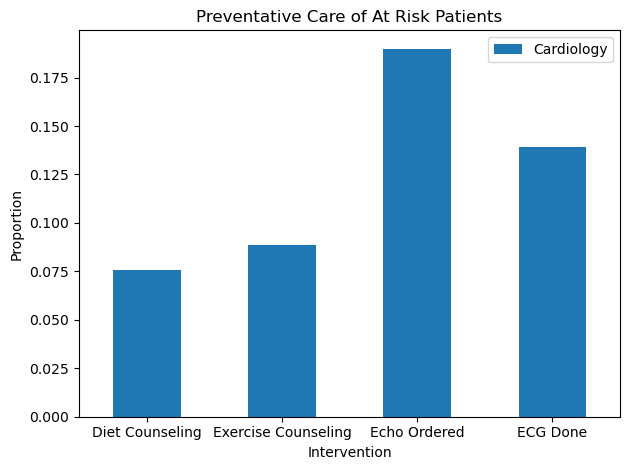

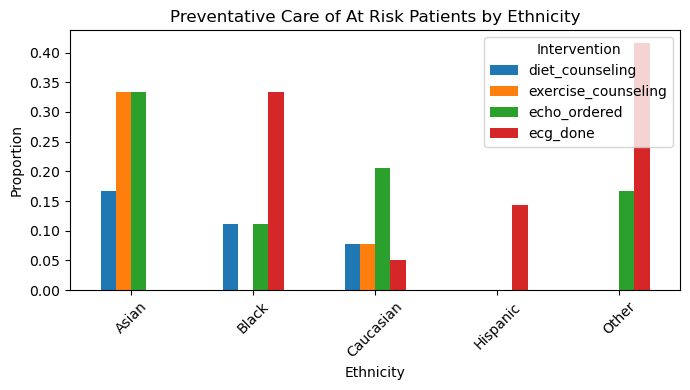

C:\Users\tiffa\AppData\Local\Temp\ipykernel_28736\1867825196.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox.groupby('age_bin')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]


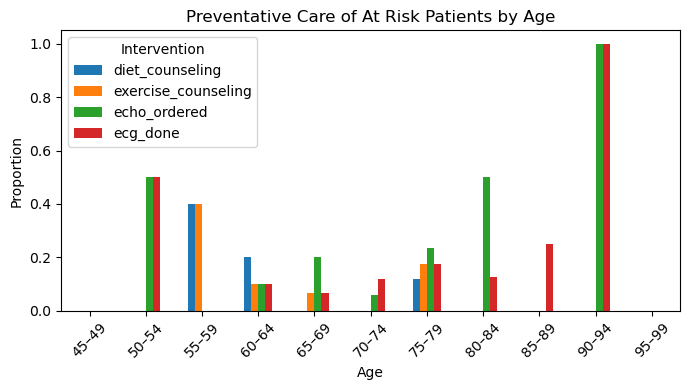

In [54]:
care = pd.DataFrame({
    "Diet Counseling": tox['diet_counseling'].mean(),
    "Exercise Counseling": tox['exercise_counseling'].mean(),
    "Echo Ordered": tox['echo_ordered'].mean(),
    "ECG Done": tox['ecg_done'].mean()
}, index=["Cardiology"])

care.T.plot(kind='bar')
plt.title("Preventative Care of At Risk Patients")
plt.xticks(rotation=0)
plt.xlabel("Intervention")
plt.ylabel("Proportion")
plt.tight_layout()

care_race = (
    tox.groupby('ethnicity')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]
    .mean()
)
care_race.plot(kind='bar', figsize=(7,4))

plt.title("Preventative Care of At Risk Patients by Ethnicity")
plt.xlabel("Ethnicity")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Intervention")

plt.tight_layout()
plt.show()

care_age = (
    tox.groupby('age_bin')[['diet_counseling', 'exercise_counseling', 'echo_ordered', 'ecg_done']]
    .mean()
)
care_age.plot(kind='bar', figsize=(7,4))

plt.title("Preventative Care of At Risk Patients by Age")
plt.xlabel("Age")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Intervention")

plt.tight_layout()
plt.show()

### Medication History

BP Treatment Pre-NHT

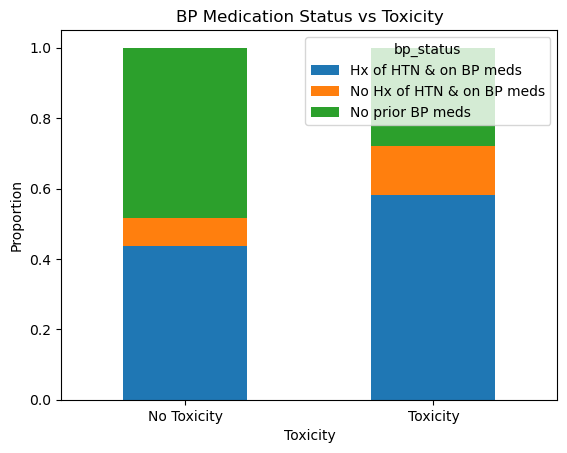

In [55]:
df['bp_status'] = np.select(
    [
        (df['hx_htn']==1) & (df['bp_meds_prior']==1),
        (df['hx_htn']==0) & (df['bp_meds_prior']==1),
        (df['bp_meds_prior']==0)
    ],
    [
        'Hx of HTN & on BP meds',
        'No Hx of HTN & on BP meds',
        'No prior BP meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['bp_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("BP Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

Diabetes Treatment Pre-NHT

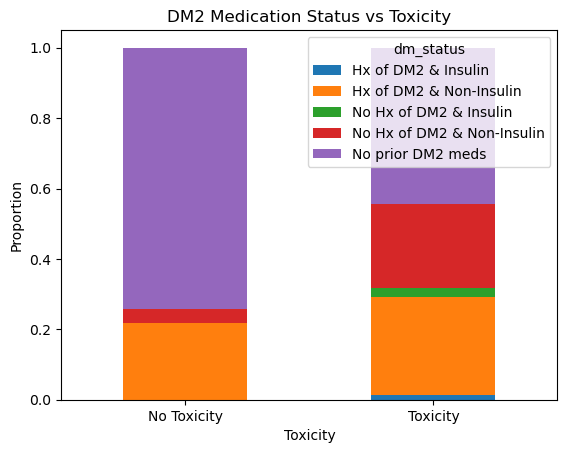

In [56]:
df['dm_status'] = np.select(
    [
        (df['hx_dm2']==1) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==1) & (df['on_insulin']==1),
        (df['hx_dm2']==0) & (df['dm_noninsulin']==1),
        (df['hx_dm2']==0) & (df['on_insulin']==1),
        (df['dm_noninsulin']==0) & (df['on_insulin']==0)
    ],
    [
        'Hx of DM2 & Non-Insulin',
        'Hx of DM2 & Insulin',
        'No Hx of DM2 & Non-Insulin',
        'No Hx of DM2 & Insulin',
        'No prior DM2 meds'
    ],
    default='Other'
)

bp_plot = pd.crosstab(df['dm_status'], df['at_risk'], normalize='columns')

ax = bp_plot.T.plot(kind='bar', stacked=True)
plt.title("DM2 Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()

HLD Treatment Pre-NHT

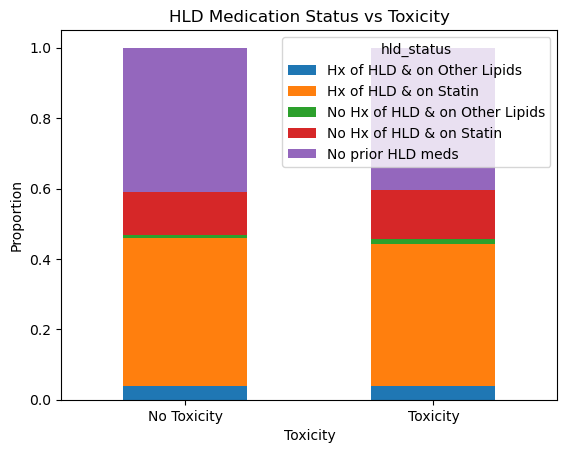

In [57]:
df['hld_status'] = np.select(
    [
        (df['hx_hld']==1) & (df['statin_prior']==1),
        (df['hx_hld']==1) & (df['other_lipid_prior']==1),
        (df['hx_hld']==0) & (df['statin_prior']==1),
        (df['hx_hld']==0) & (df['other_lipid_prior']==1),
        (df['statin_prior']==0) & (df['other_lipid_prior']==0)
    ],
    [
    'Hx of HLD & on Statin',
    'Hx of HLD & on Other Lipids',
    'No Hx of HLD & on Statin',
    'No Hx of HLD & on Other Lipids',
    'No prior HLD meds'
    ],
    default='Other'
)

statin_plot = pd.crosstab(df['hld_status'], df['at_risk'], normalize='columns')

ax = statin_plot.T.plot(kind='bar', stacked=True)
plt.title("HLD Medication Status vs Toxicity")
plt.xlabel("Toxicity")
plt.ylabel("Proportion")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Toxicity', 'Toxicity'], rotation=0)

plt.show()